In [1]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
from google.colab import files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/Dataset"
print("Contents of dataset folder:")
print(os.listdir(dataset_path))

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    count = len(os.listdir(folder_path))
    print(f"{folder}: {count} images")

Contents of dataset folder:
['Peace Sign', 'Closed Fist', 'Open Palm', 'Point Finger', 'Thumbs Up']
Peace Sign: 200 images
Closed Fist: 228 images
Open Palm: 197 images
Point Finger: 202 images
Thumbs Up: 188 images


In [4]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [5]:
train_data = datagen.flow_from_directory(dataset_path, target_size=(128, 128), batch_size=32, class_mode="categorical", subset="training")

Found 814 images belonging to 5 classes.


In [6]:
validation_data = datagen.flow_from_directory(dataset_path, target_size=(128, 128), batch_size=32, class_mode="categorical", subset="validation", shuffle=False )

Found 201 images belonging to 5 classes.


In [7]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.3))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
    mode='min'
)



history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 740s 28s/step - accuracy: 0.2039 - loss: 2.0198 - val_accuracy: 0.1990 - val_loss: 1.6083
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.3391 - loss: 1.5305 - val_accuracy: 0.3085 - val_loss: 1.5278
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 118s 5s/step - accuracy: 0.3956 - loss: 1.2836 - val_accuracy: 0.3731 - val_loss: 1.4181
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.4435 - loss: 1.1932 - val_accuracy: 0.3831 - val_loss: 1.3472
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.5504 - loss: 1.0529 - val_accuracy: 0.5572 - val_loss: 1.1868
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.6953 - loss: 0.8230 - val_accuracy: 0.5423 - val_loss: 1.1263
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.7678 - loss: 0.6471 - val_accuracy: 0.4876 - val_loss: 1.1568
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 111s 4s/step - accuracy: 0.8157 - loss: 0.5042 - val_accuracy: 0.4925 - 

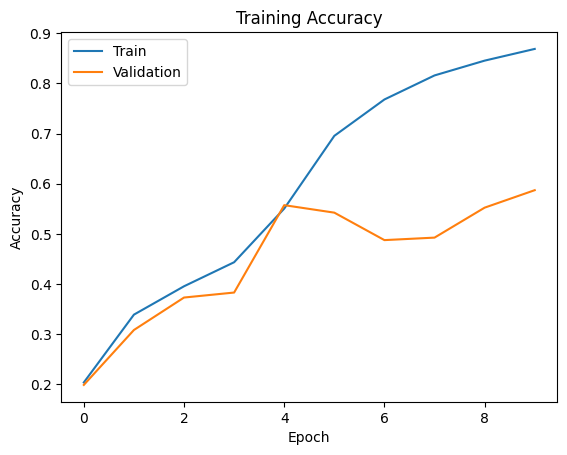

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [11]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy: 0.5522 - loss: 1.1182
Validation Accuracy: 0.5522388219833374


In [12]:
validation_data.reset()

predictions = model.predict(validation_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_labels = validation_data.classes[:len(predicted_classes)]

class_names = list(train_data.class_indices.keys())

cm = confusion_matrix(true_labels, predicted_classes)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(true_labels, predicted_classes, target_names=class_names))

7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step
Confusion Matrix:
[[32  4  2  1  6]
 [ 0 21  0  0 18]
 [ 0  1 13 16 10]
 [ 1  4  3 23  9]
 [ 0  0  5 10 22]]

              precision    recall  f1-score   support

 Closed Fist       0.97      0.71      0.82        45
   Open Palm       0.70      0.54      0.61        39
  Peace Sign       0.57      0.33      0.41        40
Point Finger       0.46      0.57      0.51        40
   Thumbs Up       0.34      0.59      0.43        37

    accuracy                           0.55       201
   macro avg       0.61      0.55      0.56       201
weighted avg       0.62      0.55      0.57       201



Saving open palm.jpg to open palm.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


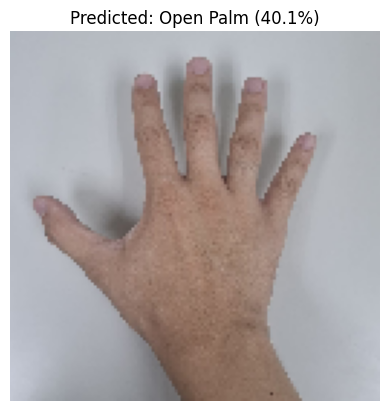

Predicted Class: Open Palm
Confidence: 40.1%


In [13]:
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.1f}%)")
plt.show()

print(f"Predicted Class: {class_labels[predicted_class]}")
print(f"Confidence: {confidence:.1f}%")